In [36]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../output/data/data_4.csv')
df.columns = ['alpha', 'beta', 'value']

pivot_df = df.pivot(index='alpha', columns='beta', values='value')

pivot_df

beta,0.000000,0.010101,0.020202,0.030303,0.040404,0.050505,0.060606,0.070707,0.080808,0.090909,...,0.909091,0.919192,0.929293,0.939394,0.949495,0.959596,0.969697,0.979798,0.989899,1.000000
alpha,,,,,,,,,,,,,,,,,,,,,
0.000000,NaN,500.000031,500.000031,499.933350,285.133362,300.400024,252.133347,199.666672,152.133347,136.200012,...,131.400009,135.800003,141.000000,148.933334,174.400009,219.466675,361.866699,438.266693,479.800018,500.000031
0.010101,500.000031,500.000031,500.000031,500.000031,437.400024,303.133362,249.466675,242.800018,170.933350,145.466675,...,131.000000,134.666672,139.333344,148.400009,165.000015,198.800003,293.866669,445.400024,432.800018,500.000031
0.020202,500.000031,500.000031,500.000031,500.000031,500.000031,413.266693,268.733337,247.466675,219.533340,165.933350,...,130.466675,134.066681,139.066681,145.666672,158.400009,189.066681,255.400009,444.466675,462.133362,500.000031
0.030303,500.000031,500.000031,500.000031,500.000031,500.000031,485.666687,369.666687,269.000000,249.333344,214.400009,...,129.666672,133.200012,137.066681,143.666672,156.466675,181.000015,237.266678,389.866699,454.333344,493.600037
0.040404,500.000031,500.000031,500.000031,500.000031,500.000031,500.000031,418.333344,365.866699,256.466675,239.000015,...,128.666672,131.533340,136.666672,142.466675,151.866669,175.066681,210.533340,385.666687,437.400024,463.933350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.959596,13.600000,13.666667,13.666667,13.666667,13.666667,13.733334,13.800001,13.800001,13.800001,13.866668,...,440.133362,446.333344,424.266693,426.266693,416.466675,414.466675,422.000031,463.133362,476.666687,477.466705
0.969697,13.600000,13.600000,13.666667,13.666667,13.666667,13.666667,13.666667,13.733334,13.800001,13.800001,...,492.466705,495.133362,457.200012,415.133362,427.133362,428.400024,413.533356,434.666687,465.266693,486.600037
0.979798,13.600000,13.600000,13.600000,13.600000,13.666667,13.666667,13.666667,13.666667,13.733334,13.800001,...,500.000031,500.000031,474.266693,459.333344,464.200012,441.000031,418.666687,450.133362,487.866699,495.133362


In [132]:
import matplotlib.pyplot as plt

def plot(data):
    fig, ax = plt.subplots()
    im = ax.imshow(data, vmin=0, vmax=500)

    label_data = [
        (50, 50, r'$\theta_{1}$'),   # (x, y, LaTeX string)
        (150, 50, r'$\theta_{2}$'),
        (150, 150, r'$\theta_{3}$'),
    ]

    # 1. Extract coordinates AND add the first point to the end to close the loop
    x_coords = [point[0] for point in label_data] + [label_data[0][0]]
    y_coords = [point[1] for point in label_data] + [label_data[0][1]]

    # 2. Draw the dashed red line connecting 1 -> 2 -> 3 -> 1
    ax.plot(
        x_coords, y_coords,
        color='red',
        linestyle='--',
        linewidth=2
    )

    # 3. Loop through and place the text labels on top
    for x, y, label in label_data:
        ax.text(
            x, y, label,
            color='white',
            fontsize=14,
            ha='center',
            va='center',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='black',
                edgecolor='none',
                alpha=0.6
            )
        )

    plt.show()

In [ ]:


df = pd.read_csv('../output/data/data_4.csv')
df.columns = ['alpha', 'beta', 'value']

pivot_df = df.pivot(index='alpha', columns='beta', values='value')

plot(pivot_df)

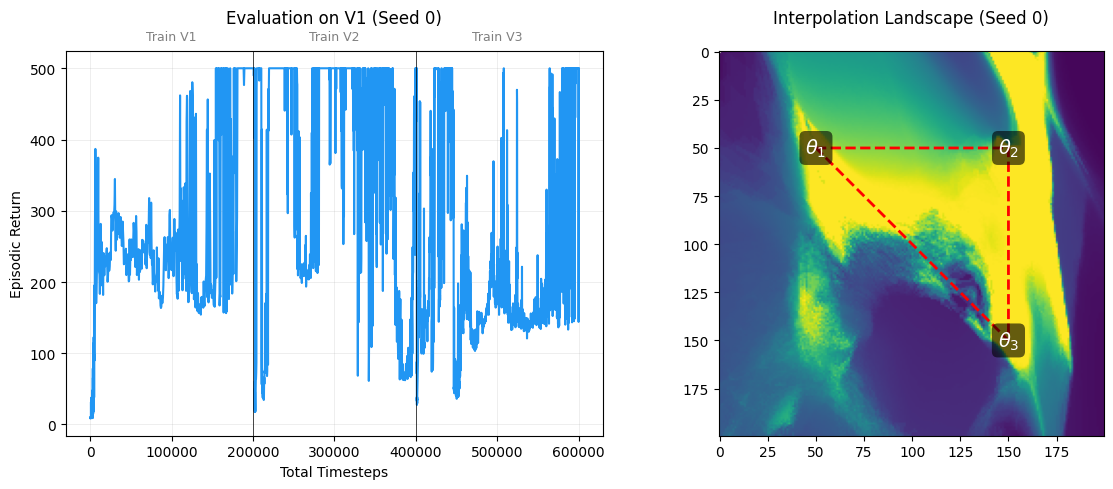

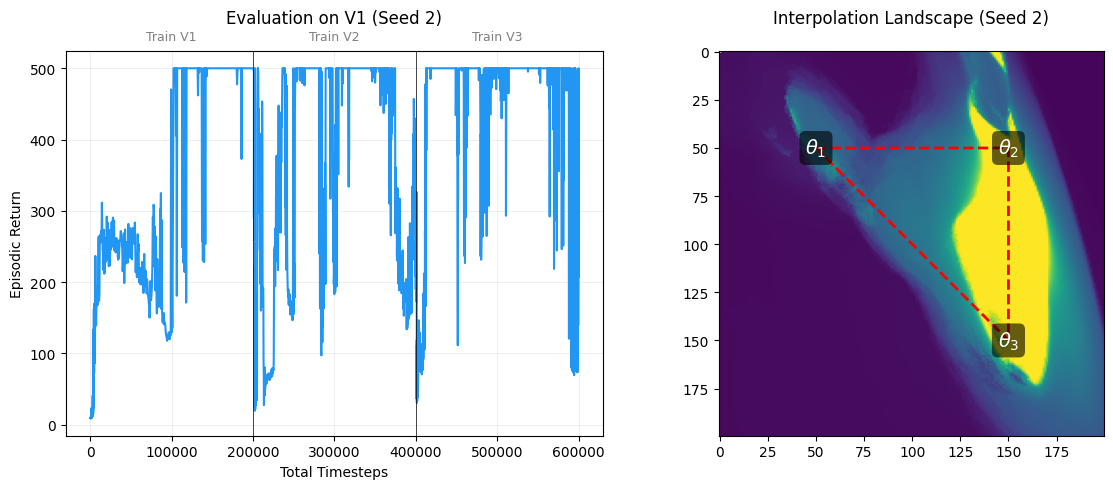

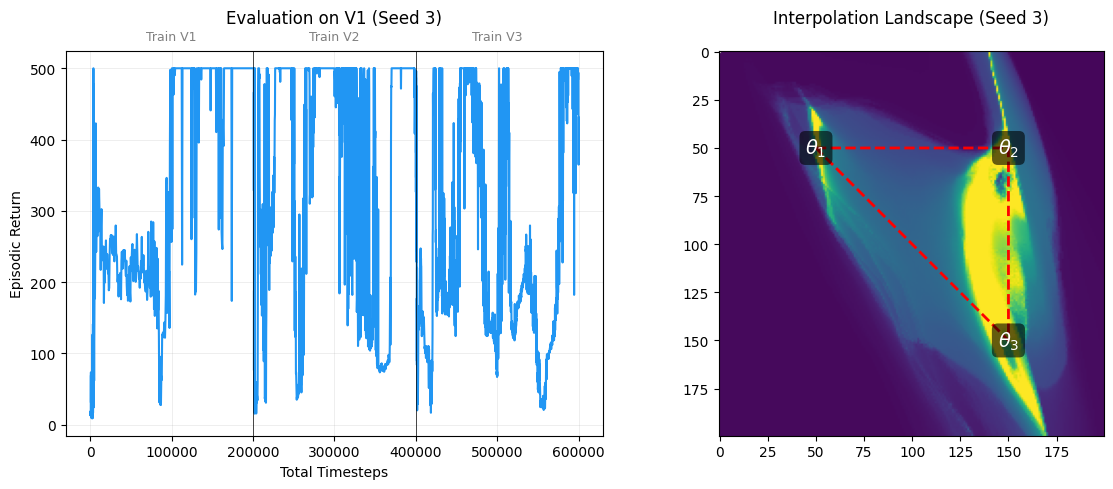

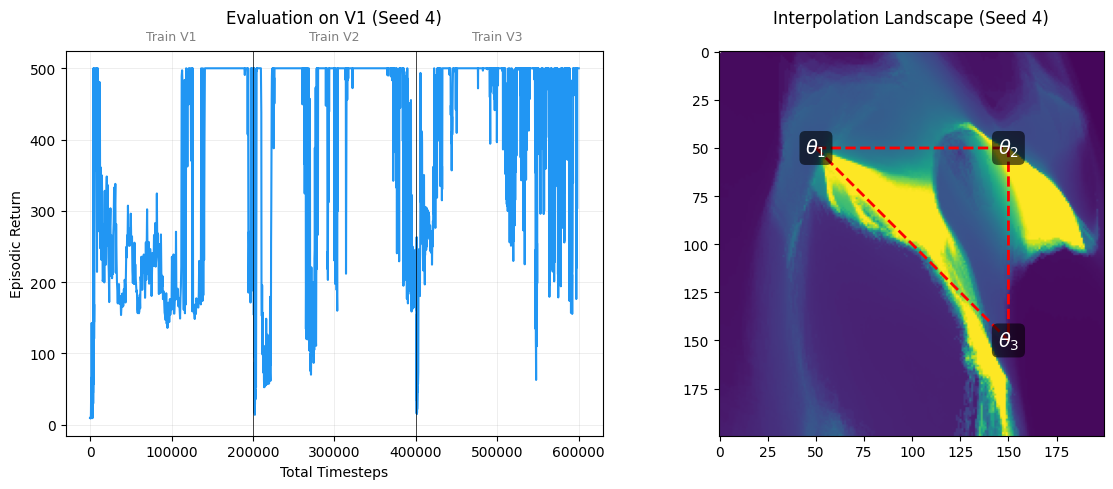

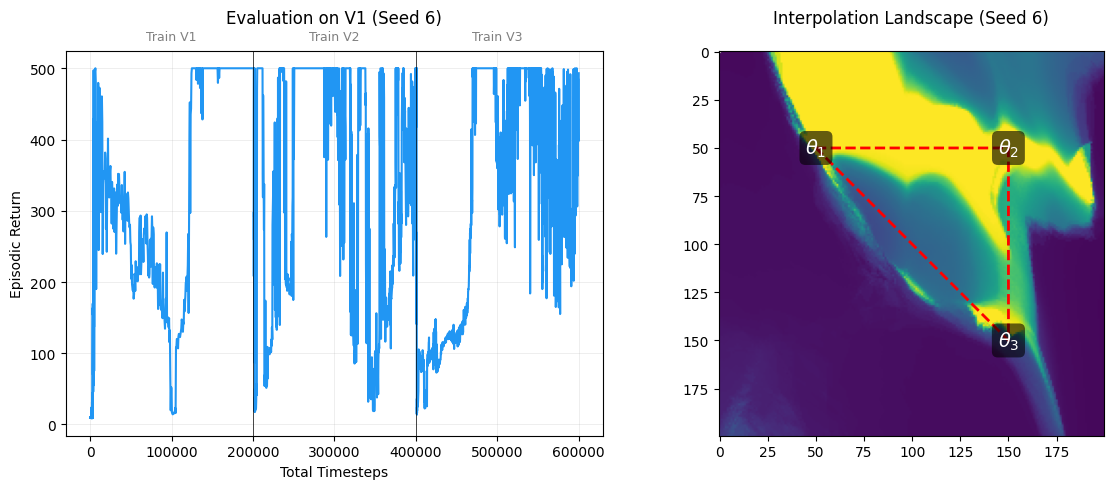

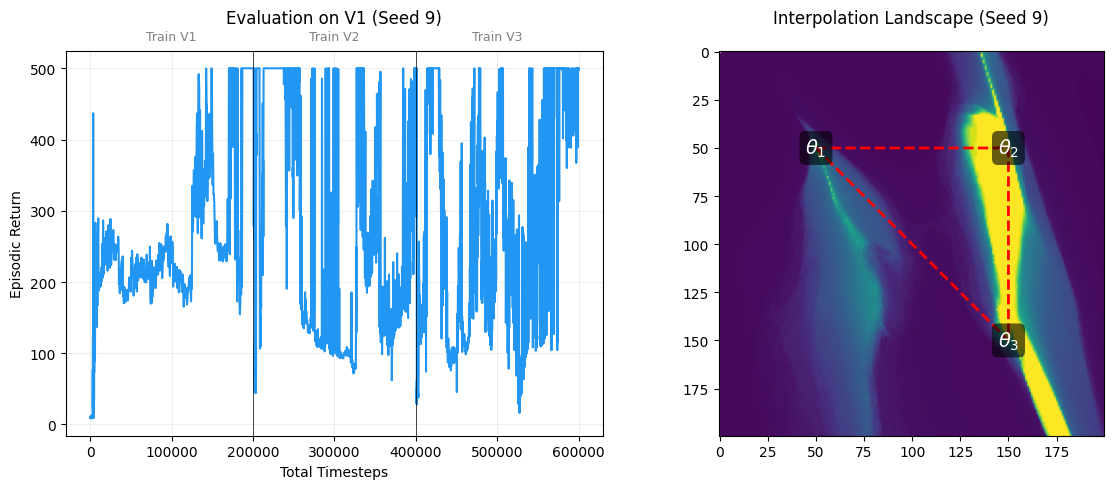

In [167]:
from plot_iqm import load_eval_data  # Imports the data loader from your script

def plot_seed_comparisons(
    seeds: list[int],
    method: str,
    test_env: str,
    heatmap_path_template: str,
    train_envs: list[str] = ["V1", "V2", "V3"],
    timesteps_per_env: int = 200_000
):
    """
    For each seed, generates a 1x2 plot:
    Left: The training/eval curve for that specific seed (styled like plot_iqm).
    Right: The interpolation heatmap with the red dashed triangle.

    heatmap_path_template: e.g., '../output/data/data_{seed}.csv'
    """

    for seed in seeds:
        # Create a side-by-side figure (12 inches wide, 5 inches tall)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # ==========================================
        # 1. LEFT PLOT: Evaluation Curve
        # ==========================================
        # Load the curve data for this specific seed
        df_eval = load_eval_data(
            method=method,
            seed=seed,
            test_env=test_env,
            train_envs=train_envs,
            timesteps_per_env=timesteps_per_env
        )

        if not df_eval.empty:
            ax1.plot(df_eval["timestep"], df_eval["reward"], color='#2196F3', linewidth=1.5)
        else:
            ax1.text(0.5, 0.5, "No eval data found", ha='center', va='center', transform=ax1.transAxes)

        ax1.set_title(f"Evaluation on {test_env} (Seed {seed})", pad=20)
        ax1.set_xlabel("Total Timesteps")
        ax1.set_ylabel("Episodic Return")
        ax1.grid(alpha=0.3)

        # Add vertical environment boundaries and "Train VX" labels
        trans = ax1.get_xaxis_transform()
        for i in range(1, len(train_envs)):
            boundary = i * timesteps_per_env
            ax1.axvline(x=boundary, color="black", linestyle="-", linewidth=0.5, zorder=5)

        for i, env in enumerate(train_envs):
            center = (i + 0.5) * timesteps_per_env
            ax1.text(center, 1.02, f"Train {env}", ha="center", va="bottom", fontsize=9, color="gray", transform=trans)

        # ==========================================
        # 2. RIGHT PLOT: Interpolation Heatmap
        # ==========================================
        # Load and pivot the heatmap data for this seed
        heatmap_path = heatmap_path_template.format(seed=seed)
        try:
            df_heat = pd.read_csv(heatmap_path)
            df_heat.columns = ['alpha', 'beta', 'value']
            pivot_df = df_heat.pivot(index='alpha', columns='beta', values='value')
            im = ax2.imshow(pivot_df, vmin=0, vmax=500)
        except FileNotFoundError:
            ax2.text(0.5, 0.5, f"Missing {heatmap_path}", ha='center', va='center', transform=ax2.transAxes)
            pivot_df = None

        if pivot_df is not None:
            # Setup labels
            label_data = [
                (50, 50, r'$\theta_{1}$'),
                (150, 50, r'$\theta_{2}$'),
                (150, 150, r'$\theta_{3}$'),
            ]

            # Extract coordinates and close the loop (1 -> 2 -> 3 -> 1)
            x_coords = [point[0] for point in label_data] + [label_data[0][0]]
            y_coords = [point[1] for point in label_data] + [label_data[0][1]]

            # Draw the red dashed line
            ax2.plot(x_coords, y_coords, color='red', linestyle='--', linewidth=2)

            # Draw the text boxes
            for x, y, label in label_data:
                ax2.text(
                    x, y, label,
                    color='white',
                    fontsize=14,
                    ha='center',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', edgecolor='none', alpha=0.6)
                )

        ax2.set_title(f"Interpolation Landscape (Seed {seed})", pad=20)

        # Ensure everything fits nicely without overlapping
        plt.tight_layout()
        plt.show()

# ==========================================
# HOW TO RUN IT
# ==========================================
if __name__ == "__main__":
    # Example: Plot for seeds 0 through 4
    my_seeds = [0, 1, 2, 3, 4]

    plot_seed_comparisons(
        seeds=list([0, 2, 3, 4, 6, 9]),
        method="dqn_cp_ji/dqn_cp_ji-s_<s>-l_00001",          # Make sure this matches the prefix of your CSVs
        test_env="V1",               # The environment you are evaluating on
        heatmap_path_template="../output/data/data_ji_{seed}.csv" # String formatting template
    )